In [ ]:
from google.colab import drive

# 1 Monte Google Drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [ ]:
import os
import glob
import torch
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

# 2 Chemin du dossier extrait sur Google Drive
dossier_path = '/content/drive/MyDrive/Nouveau/Lung250M_4B/Lung250M_4B'

# 3 Lister les fichiers dans le dossier
fichiers = os.listdir(dossier_path)
print("Fichiers dans le dossier :", fichiers)

%matplotlib inline

# 3. Lister les fichiers images et masques
images_train = sorted(glob.glob(os.path.join(dossier_path, "imagesTr", "*.nii.gz")))
labels_train = sorted(glob.glob(os.path.join(dossier_path, "masksTr", "*.nii.gz")))

# Lister les fichiers de test (imagesTs et masksTs)
images_test = sorted(glob.glob(os.path.join(dossier_path, "imagesTs", "*.nii.gz")))
labels_test = sorted(glob.glob(os.path.join(dossier_path, "masksTs", "*.nii.gz")))

# 4. Afficher le nombre d'images et de masques
print('Nombre d\'images :', len(images_train), 'Nombre de masques :', len(labels_train))

Fichiers dans le dossier : ['imagesTs', 'imagesTr', 'masksTs', 'masksTr']
Nombre d'images : 22 Nombre de masques : 22


In [ ]:
#!pip install --force-reinstall numpy monai einops timm

In [ ]:
from monai.utils import first, set_determinism

set_determinism(seed=0) # Pour fixer la seed dés le départ

In [ ]:
# 1. Créer une liste de dictionnaires pour les paires image-masque d'entraînement
train_data_dicts = [
    {"image": image_name, "label": label_name}
    for image_name, label_name in zip(images_train, labels_train)
]

# 2. Diviser les données d'entraînement en train/val (par exemple 85%/15%)
train_split = int(0.84 * len(train_data_dicts))
train_files = train_data_dicts[:train_split]
val_files = train_data_dicts[train_split:]

# 3. Créer une liste de dictionnaires pour les données de test
test_files = [
    {"image": image_name, "label": label_name}
    for image_name, label_name in zip(images_test, labels_test)
]

# 4. Afficher le nombre de fichiers dans chaque ensemble
print(f"Entraînement : {len(train_files)} fichiers")
print(f"Validation : {len(val_files)} fichiers")
print(f"Test : {len(test_files)} fichiers")

Entraînement : 18 fichiers
Validation : 4 fichiers
Test : 30 fichiers


In [ ]:
from monai.transforms import (
    AsDiscrete,
    AsDiscreted,
    EnsureChannelFirstd,
    Compose,
    CropForegroundd,
    LoadImaged,
    Orientationd,
    RandAffined,
    RandFlipd,
    RandScaleIntensityd,
    RandShiftIntensityd,
    RandSpatialCropd,
    SaveImaged,
    ScaleIntensityRanged,
    Spacingd,
    Invertd,
)
from monai.data import CacheDataset, DataLoader, Dataset, decollate_batch


test_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    ScaleIntensityRanged(keys=["image"], a_min=-1000, a_max=1000, b_min=0.0, b_max=1.0, clip=True),
    #ScaleIntensityRanged(keys=["label"], a_min=0, a_max=255, b_min=0.0, b_max=1.0, clip=True),
    CropForegroundd(keys=["image", "label"], source_key="image"),
    Orientationd(keys=["image", "label"], axcodes="PLS"),
    Spacingd(keys=["image", "label"], pixdim=(1.5, 1.5, 2.0), mode=("bilinear", "nearest")),
])

/usr/local/lib/python3.11/dist-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.croppad.dictionary CropForegroundd.__init__:allow_smaller: Current default value of argument `allow_smaller=True` has been deprecated since version 1.2. It will be changed to `allow_smaller=False` in version 1.5.
  warn_deprecated(argname, msg, warning_category)


In [ ]:
# Créer les datasets avec CacheDataset

test_ds = CacheDataset(data=test_files, transform=test_transforms, cache_rate=1.0)

# Créer les DataLoaders

test_loader = DataLoader(test_ds, batch_size=1)


Loading dataset: 100%|██████████| 30/30 [01:28<00:00,  2.96s/it]


In [ ]:
from monai.losses import DiceLoss
from monai.metrics import DiceMetric
from monai.networks.nets import UNet
from monai.networks.layers import Norm

device = torch.device("cuda:0")
model_UNet = UNet(
    spatial_dims=3,
    in_channels=1,
    out_channels=2,
    channels=(16, 32, 64, 128, 256),
    strides=(2, 2, 2, 2),
    num_res_units=2,
    norm=Norm.BATCH,
).to(device)
loss_function = DiceLoss(to_onehot_y=True, softmax=True)
optimizer = torch.optim.Adam(model_UNet.parameters(), 1e-4)
dice_metric = DiceMetric(include_background=False, reduction="mean")

In [ ]:
# 2. Installation des dépendances
import os
import glob
import torch
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

from monai.utils import first, set_determinism
from monai.data import Dataset, DataLoader, CacheDataset, decollate_batch
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, Spacingd, Orientationd,
    ScaleIntensityRanged, CropForegroundd, RandCropByPosNegLabeld,
    RandAffined, AsDiscrete, AsDiscreted, Invertd, SaveImaged
)
from monai.metrics import DiceMetric
from monai.losses import DiceLoss
from monai.inferers import sliding_window_inference

import einops
from einops.layers.torch import Rearrange

In [ ]:
test_ds = Dataset(data=test_files, transform=test_transforms )
test_loader = DataLoader(test_ds, batch_size=1)

post_transforms = Compose([
    Invertd(
        keys="pred",
        transform=test_transforms ,
        orig_keys="image",
        meta_keys="pred_meta_dict",
        orig_meta_keys="image_meta_dict",
        meta_key_postfix="meta_dict",
        nearest_interp=False,
        to_tensor=True,
    ),
    AsDiscreted(keys="pred", argmax=True, to_onehot=2),
    SaveImaged(keys="pred", meta_keys="pred_meta_dict", output_dir="./out", output_postfix="seg", resample=False),
])

In [ ]:
# Les importation
import torch
from torch import nn, einsum
import torch.nn.functional as F # Import pour le padding
from einops import rearrange, repeat
from einops.layers.torch import Rearrange
from typing import Union, List
import numpy as np
from timm.models.layers import trunc_normal_


class CyclicShift3D(nn.Module): # Décale cycliquement les volumes 3D
    def __init__(self, displacement):
        super().__init__()
        # displacement correspond à combien on déplace dans chaque axe
        assert type(displacement) is int or len(displacement) == 3, f'displacement must be 1 or 3 dimension'
        if type(displacement) is int:
            displacement = np.array([displacement, displacement, displacement])
        self.displacement = displacement

    def forward(self, x):
        # torch.roll est utilisé pour décaler cycliquement les élements d'un tenseur.
        # x est l'entrée du modèle c'est à dire le tenseur que sera traité.
        # shifts = décalage sur chaque dimensions et dims=(1,2,3) signifie que les 3 dimension seront traité
        return torch.roll(x, shifts=(self.displacement[0], self.displacement[1], self.displacement[2]), dims=(1, 2, 3))


class Residual3D(nn.Module): #permet d'ajouter une connexion résiduelle dans un réseau 3D
    def __init__(self, fn):
        super().__init__()
        self.fn = fn

    def forward(self, x, **kwargs):
        return self.fn(x, **kwargs) + x


class PreNorm3D(nn.Module): #pour appliquer une normalisation sur les entrées avant de passer à une transformation
    def __init__(self, dim, fn):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.fn = fn

    def forward(self, x, **kwargs):
        return self.fn(self.norm(x), **kwargs)


class FeedForward3D(nn.Module): # transforme les données en passant par 2 couches avec une activation entre elles
    def __init__(self, dim, hidden_dim, dropout: float = 0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, hidden_dim), # première couche pour transformer l'entrée de taille dim en hidden_dim
            nn.GELU(), # dans les transformers, GELU donne de meilleur performance que RELU
            nn.Linear(hidden_dim, dim), # deuxième couche pour ramener à la dimension d'origine(dim)
        )
        self.drop = nn.Dropout(dropout) if dropout > 0 else nn.Identity() # pour éviter le surapprentissage avec un taux = dropout

    def forward(self, x):
        x = self.net(x)
        x = self.drop(x)
        return x


def create_mask3D(window_size: Union[int, List[int]], displacement: Union[int, List[int]], x_shift: bool, y_shift: bool, z_shift: bool):
    # cette fonction crée un masque 3D pour bloquer l'attention entre certaines positions dans un espace 3D.
    assert type(window_size) is int or len(window_size) == 3, f'window_size must be 1 or 3 dimension'  #vérifie que la taille du cube est un entier et liste de 3 entier
    if type(window_size) is int:
        window_size = np.array([window_size, window_size, window_size])

    assert type(displacement) is int or len(displacement) == 3, f'displacement must be 1 or 3 dimension'
    if type(displacement) is int:
        displacement = np.array([displacement, displacement, displacement])

    assert len(window_size) == len(displacement)
    for i in range(len(window_size)):
        assert 0 < displacement[i] < window_size[i], f'Décalage invalide sur l’axe {i} — les axes sont X(i=0), Y(i=1), Z(i=2)'

    mask = torch.zeros(window_size[0] * window_size[1] * window_size[2], window_size[0] * window_size[1] * window_size[2])  # (wx*wy*wz, wx*wy*wz)
    mask = rearrange(mask, '(x1 y1 z1) (x2 y2 z2) -> x1 y1 z1 x2 y2 z2', x1=window_size[0], y1=window_size[1], x2=window_size[0], y2=window_size[1])

    x_dist, y_dist, z_dist = displacement[0], displacement[1], displacement[2]

    if x_shift:
        #      x1     y1 z1     x2     y2 z2
        mask[-x_dist:, :, :, :-x_dist, :, :] = float('-inf')
        mask[:-x_dist, :, :, -x_dist:, :, :] = float('-inf')

    if y_shift:
        #   x1   y1       z1 x2  y2       z2
        mask[:, -y_dist:, :, :, :-y_dist, :] = float('-inf')
        mask[:, :-y_dist, :, :, -y_dist:, :] = float('-inf')

    if z_shift:
        #   x1  y1  z1       x2 y2  z2
        mask[:, :, -z_dist:, :, :, :-z_dist] = float('-inf')
        mask[:, :, :-z_dist, :, :, -z_dist:] = float('-inf')

    mask = rearrange(mask, 'x1 y1 z1 x2 y2 z2 -> (x1 y1 z1) (x2 y2 z2)')
    return mask


def get_relative_distances(window_size):  # cette fonction calcule les distances entre chaque voxel dans un cube 3D
    assert type(window_size) is int or len(window_size) == 3, f'window_size must be 1 or 3 dimension'
    if type(window_size) is int:
        window_size = np.array([window_size, window_size, window_size])
    indices = torch.tensor( np.array([[x, y, z] for x in range(window_size[0]) for y in range(window_size[1]) for z in range(window_size[2])])) # crée toutes les positions 3D dans la fenêtre

    distances = indices[None, :, :] - indices[:, None, :] #pour chaque paire de positions, calcule la diffèrence [dx,dy,dz]
    # distance:(n,n,3) n =window_size[0]*window_size[1]*window_size[2]
    return distances


class WindowAttention3D(nn.Module):
    #but de la classe : faire de l'attention dans  un cube 3D, fenetré et parfois décalé pour capturer plus de contexte local
    def __init__(self, dim: int, heads: int, head_dim: int, shifted: bool, window_size: Union[int, List[int]], relative_pos_embedding: bool = True):
        super().__init__()

        assert type(window_size) is int or len(window_size) == 3, f'window_size must be 1 or 3 dimension'
        if type(window_size) is int:
            window_size = np.array([window_size, window_size, window_size]) #on crée un cube
        else:
            window_size = np.array(window_size)

        inner_dim = head_dim * heads
        self.heads = heads
        self.scale = head_dim ** -0.5
        self.window_size = window_size
        self.shifted = shifted

        if self.shifted:
            displacement = window_size // 2
            self.cyclic_shift = CyclicShift3D(-displacement)
            self.cyclic_back_shift = CyclicShift3D(displacement)
            self.x_mask = nn.Parameter(create_mask3D(window_size=window_size, displacement=displacement,
                                                     x_shift=True, y_shift=False, z_shift=False), requires_grad=False)
            self.y_mask = nn.Parameter(create_mask3D(window_size=window_size, displacement=displacement,
                                                     x_shift=False, y_shift=True, z_shift=False), requires_grad=False)
            self.z_mask = nn.Parameter(create_mask3D(window_size=window_size, displacement=displacement,
                                                     x_shift=False, y_shift=False, z_shift=True), requires_grad=False)

        self.to_qkv = nn.Linear(dim, inner_dim * 3, bias=False)  #génération de QKV chacun ayant la même dimension.


        self.softmax = nn.Softmax(dim=-1) #transforme un vecteur de score en probabilités et dim=-1 signifie que la normalisation va se faire sur la dernière dimension de chaque vecteur
        self.to_out = nn.Linear(inner_dim, dim)

    def forward(self, x):
        if self.shifted:
            x = self.cyclic_shift(x)

        b, n_x, n_y, n_z, _, h = *x.shape, self.heads

        qkv = self.to_qkv(x).chunk(3, dim=-1)
        nw_x = n_x // self.window_size[0]
        nw_y = n_y // self.window_size[1]
        nw_z = n_z // self.window_size[2]

        q, k, v = map(
            lambda t: rearrange(t, 'b (nw_x w_x) (nw_y w_y) (nw_z w_z) (h d) -> b h (nw_x nw_y nw_z) (w_x w_y w_z) d',
                                h=h, w_x=self.window_size[0], w_y=self.window_size[1], w_z=self.window_size[2]), qkv)

        dots = einsum('b h w i d, b h w j d -> b h w i j', q, k) * self.scale  # Produit scalaire entre q et k pour obtenir les scores d'attention

        if self.shifted:
            dots = rearrange(dots, 'b h (n_x n_y n_z) i j -> b h n_y n_z n_x i j',
                             n_x=nw_x, n_y=nw_y)
            dots[:, :, :, :, -1] += self.x_mask

            dots = rearrange(dots, 'b h n_y n_z n_x i j -> b h n_x n_z n_y i j')
            dots[:, :, :, :, -1] += self.y_mask

            dots = rearrange(dots, 'b h n_x n_z n_y i j -> b h n_x n_y n_z i j')
            dots[:, :, :, :, -1] += self.z_mask

            dots = rearrange(dots, 'b h n_y n_z n_x i j -> b h (n_x n_y n_z) i j')


        attn = self.softmax(dots)
        out = einsum('b h w i j, b h w j d -> b h w i d', attn, v)
        out = rearrange(out, 'b h (nw_x nw_y nw_z) (w_x w_y w_z) d -> b (nw_x w_x) (nw_y w_y) (nw_z w_z) (h d)',
                        h=h, w_x=self.window_size[0], w_y=self.window_size[1], w_z=self.window_size[2],
                        nw_x=nw_x, nw_y=nw_y, nw_z=nw_z)
        out = self.to_out(out)

        if self.shifted:
            out = self.cyclic_back_shift(out)
        return out


class SwinBlock3D(nn.Module):  #capture les dépendances à longue distance dans les images 3D via une attention multi-têtes localisée
    def __init__(self, dim, heads, head_dim, mlp_dim, shifted, window_size: Union[int, List[int]],
                 relative_pos_embedding: bool = True, dropout: float = 0.0):
        super().__init__()
        self.attention_block = Residual3D(PreNorm3D(dim, WindowAttention3D(dim=dim,
                                                                           heads=heads,
                                                                           head_dim=head_dim,
                                                                           shifted=shifted,
                                                                           window_size=window_size,
                                                                           relative_pos_embedding=relative_pos_embedding)))
        self.mlp_block = Residual3D(PreNorm3D(dim, FeedForward3D(dim=dim, hidden_dim=mlp_dim, dropout=dropout)))

    def forward(self, x):
        x = self.attention_block(x)
        x = self.mlp_block(x)
        return x


class Norm(nn.Module): #normalisation sur les features
    def __init__(self, dim, channel_first: bool = True):
        super(Norm, self).__init__()
        if channel_first:
            self.net = nn.Sequential(
                Rearrange('b c h w d -> b h w d c'),
                nn.LayerNorm(dim),
                Rearrange('b h w d c -> b c h w d')
            )

            # self.net = nn.InstanceNorm3d(dim, eps=1e-5, momentum=0.1, affine=False)
        else:
            self.net = nn.LayerNorm(dim)

    def forward(self, x):
        x = self.net(x)
        return x


class PatchMerging3D(nn.Module): # faire un downsampling 3D (réduction de taille spatiale + profondeur) tout en augmentant la richesse des features
    #c'est un peu comme fusionner plusieurs petits cubes(patchs) en un plus gros, pour capturer plus de contexte
    def __init__(self, in_dim, out_dim, downscaling_factor):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv3d(in_dim, out_dim, kernel_size=downscaling_factor, stride=downscaling_factor),
            Norm(dim=out_dim),
        )

    def forward(self, x):
        # x: B, C, H, W, D
        x = self.net(x)
        return x  # B,  H //down_scaling, W//down_scaling, D//down_scaling, out_dim


class PatchExpanding3D(nn.Module): #pour créer une version plus grande du volume 3D, avec une résolution plus fine (X,Y,Z)
    def __init__(self, in_dim, out_dim, up_scaling_factor):
        super(PatchExpanding3D, self).__init__()

        stride = up_scaling_factor
        kernel_size = up_scaling_factor
        padding = (kernel_size - stride) // 2
        self.net = nn.Sequential(
            nn.ConvTranspose3d(in_dim, out_dim, kernel_size=kernel_size, stride=stride, padding=padding),
            Norm(out_dim),
        )

    def forward(self, x):
        '''X: B,C,X,Y,Z'''
        x = self.net(x)
        return x


class FinalExpand3D(nn.Module):  # sert à agrandir un volume 3D (upscaling) et à générer une sortie finale (ex: classes) avec normalisation et activation.
    def __init__(self, in_dim, out_dim, up_scaling_factor):
        super(FinalExpand3D, self).__init__()

        stride = up_scaling_factor
        kernel_size = up_scaling_factor
        padding = (kernel_size - stride) // 2
        self.net = nn.Sequential(
            nn.ConvTranspose3d(in_dim, out_dim, kernel_size=kernel_size, stride=stride, padding=padding),
            Norm(out_dim),
            nn.PReLU()
        )

    def forward(self, x):
        '''X: B,C,H,W,D'''
        x = self.net(x)
        return x


class ConvBlock(nn.Module):  # bloc de convolution avec 2 convolution successives sur les données d'entrée
    def __init__(self, in_ch, out_ch):
        super(ConvBlock, self).__init__()
        groups = min(in_ch, out_ch)
        self.net = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, kernel_size=3, stride=1, padding=1, groups=groups),
            Norm(dim=out_ch),
            nn.PReLU(),

            nn.Conv3d(out_ch, out_ch, kernel_size=3, stride=1, padding=1, groups=groups),
            Norm(dim=out_ch),
            nn.PReLU(),
        )

    def forward(self, x):
        x2 = x.clone()
        x = self.net(x) * x2
        return x


class Encoder(nn.Module):
    def __init__(self, in_dims, hidden_dimension, layers, downscaling_factor, num_heads, head_dim,
                 window_size: Union[int, List[int]], relative_pos_embedding: bool = True, dropout: float = 0.0):
        super().__init__()
        assert layers % 2 == 0, 'Stage layers need to be divisible by 2 for regular and shifted block.'

        self.patch_partition = PatchMerging3D(in_dim=in_dims, out_dim=hidden_dimension,downscaling_factor=downscaling_factor)
        self.conv_block = ConvBlock(in_ch=hidden_dimension, out_ch=hidden_dimension)

        self.re1 = Rearrange('b c h w d -> b h w d c')
        self.swin_layers = nn.ModuleList([])
        for _ in range(layers // 2):
            self.swin_layers.append(nn.ModuleList([
                SwinBlock3D(dim=hidden_dimension, heads=num_heads, head_dim=head_dim, mlp_dim=hidden_dimension * 4,
                            shifted=False, window_size=window_size, relative_pos_embedding=relative_pos_embedding, dropout=dropout),
                SwinBlock3D(dim=hidden_dimension, heads=num_heads, head_dim=head_dim, mlp_dim=hidden_dimension * 4,
                            shifted=True, window_size=window_size, relative_pos_embedding=relative_pos_embedding, dropout=dropout),
            ]))
        self.re2 = Rearrange('b  h w d c -> b c h w d')

    def forward(self, x):
        x = self.patch_partition(x)
        x2 = self.conv_block(x)  # Le bloc convolutionnel apprend des dépendances à courte portée.

        x = self.re1(x)
        for regular_block, shifted_block in self.swin_layers:  # Le bloc swin_layers apprend des dépendances à longue portée
            x = regular_block(x)
            x = shifted_block(x)
        x = self.re2(x)

        x = x + x2  # Fusionner les informations de dépendance à courte et longue portée
        return x


class Decoder(nn.Module):
    def __init__(self, in_dims, out_dims, layers, up_scaling_factor, num_heads, head_dim, window_size: Union[int, List[int]], relative_pos_embedding, dropout: float = 0.0):
        super().__init__()
        assert layers % 2 == 0, 'Stage layers need to be divisible by 2 for regular and shifted block.'

        self.patch_expand = PatchExpanding3D(in_dim=in_dims, out_dim=out_dims, up_scaling_factor=up_scaling_factor)

        self.conv_block = ConvBlock(in_ch=out_dims, out_ch=out_dims)
        self.re1 = Rearrange('b c h w d -> b h w d c')
        self.swin_layers = nn.ModuleList([])
        for _ in range(layers // 2):
            self.swin_layers.append(nn.ModuleList([
                SwinBlock3D(dim=out_dims, heads=num_heads, head_dim=head_dim, mlp_dim=out_dims * 4,
                            shifted=False, window_size=window_size, relative_pos_embedding=relative_pos_embedding, dropout=dropout),
                SwinBlock3D(dim=out_dims, heads=num_heads, head_dim=head_dim, mlp_dim=out_dims * 4,
                            shifted=True, window_size=window_size, relative_pos_embedding=relative_pos_embedding, dropout=dropout),
            ]))
        self.re2 = Rearrange('b h w d c -> b c h w d')

    def forward(self, x):
        x = self.patch_expand(x)

        x2 = self.conv_block(x)

        x = self.re1(x)
        for regular_block, shifted_block in self.swin_layers:
            x = regular_block(x)
            x = shifted_block(x)
        x = self.re2(x)

        x = x + x2
        return x


class Converge(nn.Module):
    def __init__(self, dim: int):
        '''
        stack : La méthode de fusion est réalisée par empilement + transformation linéaire.
        add : Les connexions résiduelles sont réalisées par addition directe.
        '''
        super(Converge, self).__init__()
        self.norm = Norm(dim=dim)

    def forward(self, x, enc_x):
        '''
         x: B,C,X,Y,Z
        enc_x:B,C,X,Y,Z
        '''
        assert x.shape == enc_x.shape
        x = x + enc_x
        x = self.norm(x)
        return x


class SwinUnet3D(nn.Module):
    def __init__(self, *, hidden_dim, layers, heads, in_channel=1, num_classes=2, head_dim=32,
                 window_size: Union[int, List[int]] = 7, downscaling_factors=(4, 2, 2, 2),
                 relative_pos_embedding=True, dropout: float = 0.0, skip_style='stack',
                 stl_channels: int = 32):  # second_to_last_channels
        super().__init__()

        self.dsf = downscaling_factors

        self.window_size = window_size

        self.enc12 = Encoder(in_dims=in_channel, hidden_dimension=hidden_dim, layers=layers[0],
                             downscaling_factor=downscaling_factors[0], num_heads=heads[0],
                             head_dim=head_dim, window_size=window_size, dropout=dropout,
                             relative_pos_embedding=relative_pos_embedding)
        self.enc3 = Encoder(in_dims=hidden_dim, hidden_dimension=hidden_dim * 2,
                            layers=layers[1],
                            downscaling_factor=downscaling_factors[1], num_heads=heads[1],
                            head_dim=head_dim, window_size=window_size, dropout=dropout,
                            relative_pos_embedding=relative_pos_embedding)
        self.enc4 = Encoder(in_dims=hidden_dim * 2, hidden_dimension=hidden_dim * 4,
                            layers=layers[2],
                            downscaling_factor=downscaling_factors[2], num_heads=heads[2],
                            head_dim=head_dim, window_size=window_size, dropout=dropout,
                            relative_pos_embedding=relative_pos_embedding)
        self.enc5 = Encoder(in_dims=hidden_dim * 4, hidden_dimension=hidden_dim * 8,
                            layers=layers[3],
                            downscaling_factor=downscaling_factors[3], num_heads=heads[3],
                            head_dim=head_dim, window_size=window_size, dropout=dropout,
                            relative_pos_embedding=relative_pos_embedding)

        self.dec4 = Decoder(in_dims=hidden_dim * 8, out_dims=hidden_dim * 4,
                            layers=layers[2],
                            up_scaling_factor=downscaling_factors[3], num_heads=heads[2],
                            head_dim=head_dim, window_size=window_size, dropout=dropout,
                            relative_pos_embedding=relative_pos_embedding)

        self.dec3 = Decoder(in_dims=hidden_dim * 4, out_dims=hidden_dim * 2,
                            layers=layers[1],
                            up_scaling_factor=downscaling_factors[2], num_heads=heads[1],
                            head_dim=head_dim, window_size=window_size, dropout=dropout,
                            relative_pos_embedding=relative_pos_embedding)

        self.dec12 = Decoder(in_dims=hidden_dim * 2, out_dims=hidden_dim,
                             layers=layers[0],
                             up_scaling_factor=downscaling_factors[1], num_heads=heads[0],
                             head_dim=head_dim, window_size=window_size, dropout=dropout,
                             relative_pos_embedding=relative_pos_embedding)

        self.converge4 = Converge(hidden_dim * 4)
        self.converge3 = Converge(hidden_dim * 2)
        self.converge12 = Converge(hidden_dim)

        self.final = FinalExpand3D(in_dim=hidden_dim, out_dim=stl_channels,
                                   up_scaling_factor=downscaling_factors[0])
        self.out = nn.Sequential(
            # nn.Linear(stl_channels, num_classes),
            # Rearrange('b h w d c -> b c h w d'),
            nn.Conv3d(stl_channels, num_classes, kernel_size=1)
        )
        # Initialisation des paramètres
        self.init_weight()

    def forward(self, img):
        window_size = self.window_size
        assert type(window_size) is int or len(window_size) == 3, f'window_size must be 1 or 3 dimension'
        if type(window_size) is int:
            window_size = np.array([window_size, window_size, window_size])

        # Get input shape
        _, _, x_s, y_s, z_s = img.shape
        x_ws, y_ws, z_ws = window_size

        # Calculate padding to make dimensions divisible by window_size * 32
        x_pad = (x_ws * 32) - (x_s % (x_ws * 32)) if x_s % (x_ws * 32) != 0 else 0
        y_pad = (y_ws * 32) - (y_s % (y_ws * 32)) if y_s % (y_ws * 32) != 0 else 0
        z_pad = (z_ws * 32) - (z_s % (z_ws * 32)) if z_s % (z_ws * 32) != 0 else 0

        # Pad the input image
        img = F.pad(img, (0, z_pad, 0, y_pad, 0, x_pad))

        down12_1 = self.enc12(img)  # (B,C, X//4, Y//4, Z//4)
        down3 = self.enc3(down12_1)  # (B, 2C,X//8, Y//8, Z//8)
        down4 = self.enc4(down3)  # (B, 4C,X//16, Y//16, Z//16)
        features = self.enc5(down4)  # (B, 8C,X//32, Y//32, Z//32)


        up4 = self.dec4(features)  # (B, 8C, X//16, Y//16, Z//16 )
        up4 = self.converge4(up4, down4)  # (B, 4C, X//16, Y//16, Z//16)

        up3 = self.dec3(up4)  # ((B, 2C,X//8, Y//8, Z//8)
        up3 = self.converge3(up3, down3)  # (B,2C, X//8, Y//8)

        up12 = self.dec12(up3)  # (B,C, X//4, Y//4, Z// 4)
        up12 = self.converge12(up12, down12_1)  # (B,C, X//4, Y//4, Z//4)

        out = self.final(up12)  # (B,num_classes, X, Y, Z)
        out = self.out(out)

        # Remove padding from the output before returning
        out = out[:, :, :x_s, :y_s, :z_s]
        return out

    def init_weight(self):
        for m in self.modules():
            if isinstance(m, (nn.Linear, nn.Conv3d, nn.ConvTranspose3d)):
                trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            if isinstance(m, nn.LayerNorm):
                nn.init.constant_(m.weight, 1.0)
                nn.init.constant_(m.bias, 0.0)



def swinUnet_t_3D(hidden_dim=96, layers=(2, 2, 6, 4), heads=(3, 6, 9, 12), num_classes: int = 2, **kwargs):
    return SwinUnet3D(hidden_dim=hidden_dim, layers=layers, heads=heads, num_classes=num_classes, **kwargs)

/usr/local/lib/python3.11/dist-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [ ]:
# 6. Initialisation
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model_swinUnet = swinUnet_t_3D(
    hidden_dim=48,
    layers=[2, 2, 6, 2],
    heads=[3, 6, 12, 24],
    in_channel=1,
    num_classes=2,
    window_size=3
).to(device)

loss_function = DiceLoss(to_onehot_y=True, softmax=True)
optimizer = torch.optim.Adam(model_swinUnet.parameters(), 1e-4)
dice_metric = DiceMetric(include_background=False, reduction="mean")

Utilisation de l'appareil : cuda
Modèle '3D_UNet_147' chargé avec succès depuis '/content/drive/MyDrive/modèle/3D_UNet_147.pth'
Modèle '3D_UNet_70' chargé avec succès depuis '/content/drive/MyDrive/modèle/3D_UNet_70.pth'
Modèle '3D_UNet_35' chargé avec succès depuis '/content/drive/MyDrive/modèle/3D_UNet_35.pth'
Modèle '3D_UNet_18' chargé avec succès depuis '/content/drive/MyDrive/modèle/3D_UNet_18.pth'
Modèle 'Swin_UNet3D_147' chargé avec succès depuis '/content/drive/MyDrive/modèle/Swin_UNet3D_147.pth'
Modèle 'Swin_UNet3D_70' chargé avec succès depuis '/content/drive/MyDrive/modèle/Swin_UNet3D_70.pth'
Modèle 'Swin_UNet3D_35' chargé avec succès depuis '/content/drive/MyDrive/modèle/Swin_UNet3D_35.pth'
Modèle 'Swin_UNet3D_18' chargé avec succès depuis '/content/drive/MyDrive/modèle/Swin_UNet3D_18.pth'

Traitement de l'image de test n°1
3D_UNet_147 - Dice: 0.8097, F1: 0.8097, Precision: 0.9059, Recall: 0.7320, Accuracy: 0.8976, MAE: 0.1024, Voxel Error: 247026.0
3D_UNet_70 - Dice: 0.972

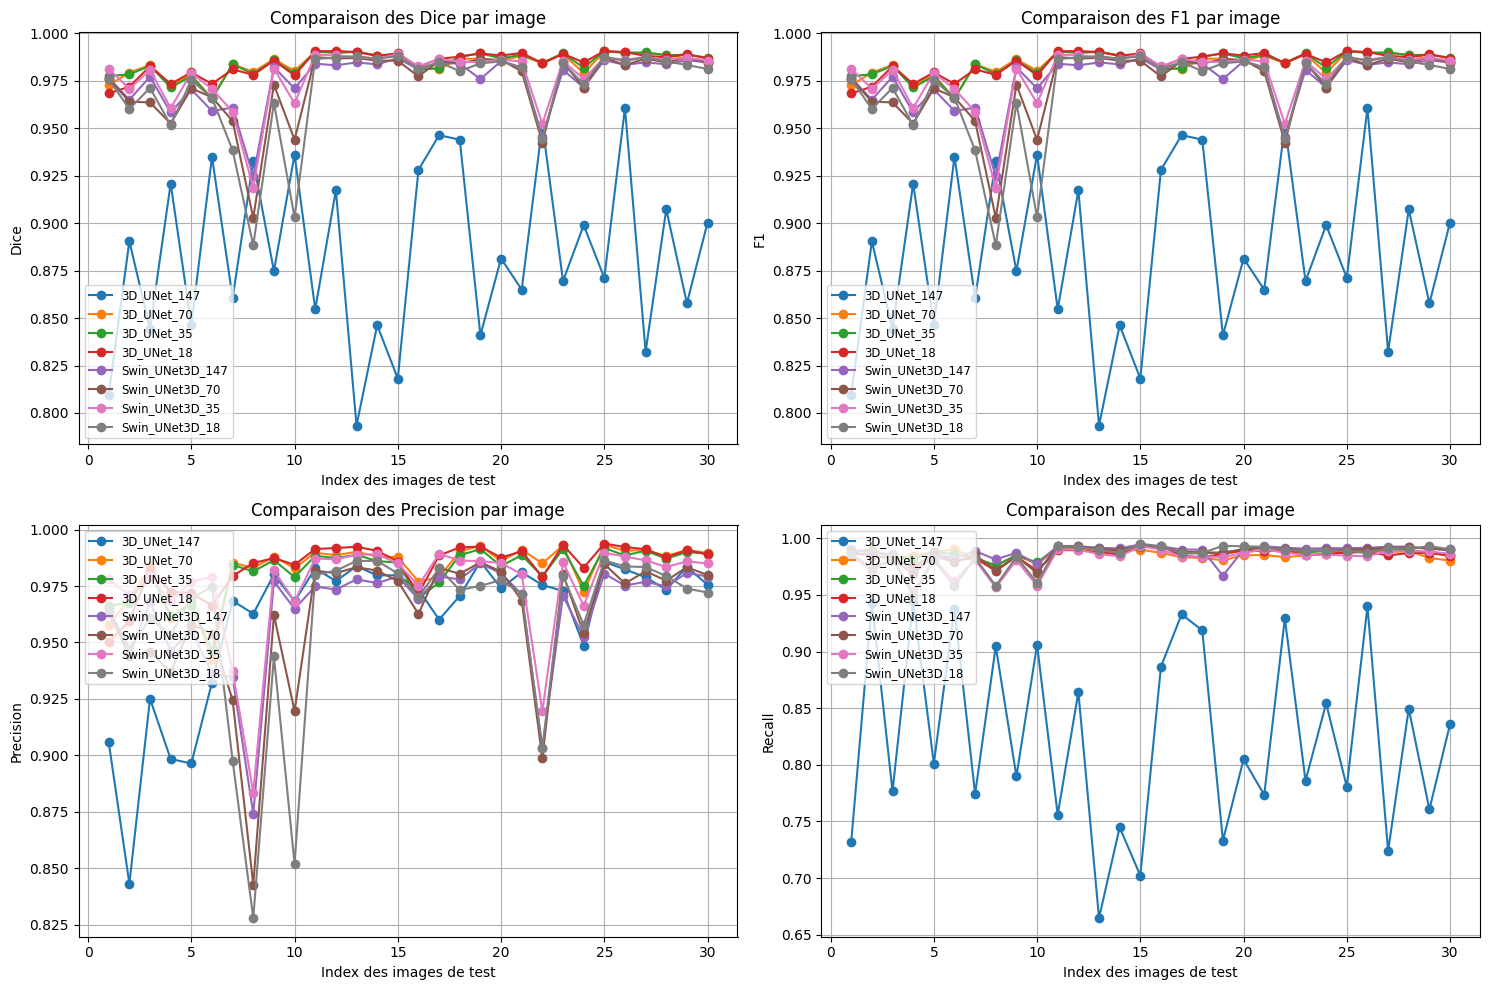

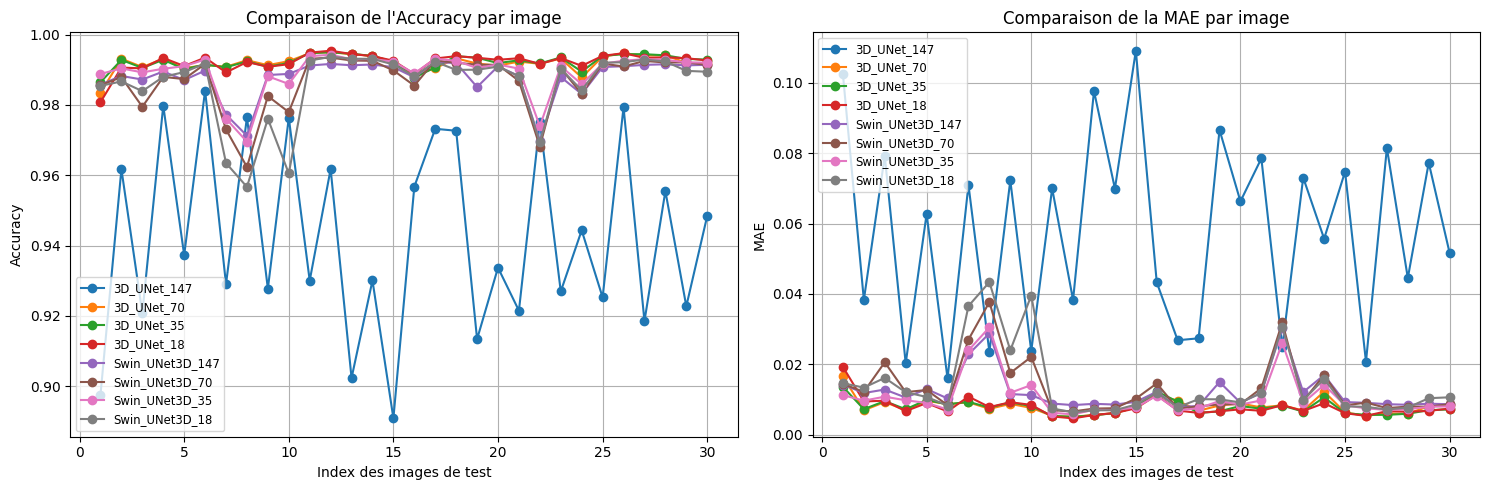

<ipython-input-14-3e5c7fc1f24c>:198: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(voxel_errors_data, labels=models_paths.keys())


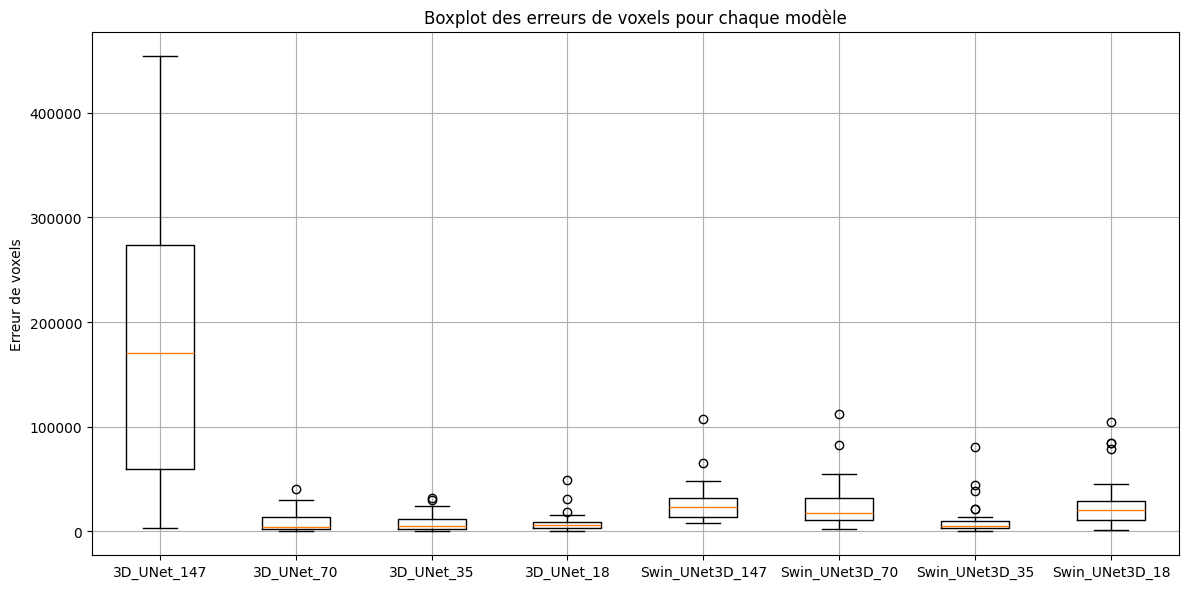

In [ ]:
import torch
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
from monai.transforms import AsDiscrete
from monai.inferers import sliding_window_inference
from monai.data import decollate_batch

# Définir un appareil pour l'exécution (GPU ou CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Utilisation de l'appareil : {device}")

# Définir les chemins vers les modèles
base_path = '/content/drive/MyDrive/modèle/'
models_paths = {
    '3D_UNet_147': base_path + "3D_UNet_147.pth",
    '3D_UNet_70': base_path + "3D_UNet_70.pth",
    '3D_UNet_35': base_path + "3D_UNet_35.pth",
    '3D_UNet_18': base_path + "3D_UNet_18.pth",
    'Swin_UNet3D_147': base_path + "Swin_UNet3D_147.pth",
    'Swin_UNet3D_70': base_path + "Swin_UNet3D_70.pth",
    'Swin_UNet3D_35': base_path + "Swin_UNet3D_35.pth",
    'Swin_UNet3D_18': base_path + "Swin_UNet3D_18.pth",
}
# Initialiser les modèles
models = {}
for model_name, model_path in models_paths.items():
    if "UNet" in model_name and "Swin" not in model_name:
        model = UNet(
            spatial_dims=3,
            in_channels=1,
            out_channels=2,
            channels=(16, 32, 64, 128, 256),
            strides=(2, 2, 2, 2),
            num_res_units=2,
            norm='BATCH',  # Utilisation de la chaîne de caractères directement
        ).to(device)
    elif "Swin" in model_name:
        model = swinUnet_t_3D(
            hidden_dim=48,
            layers=[2, 2, 6, 2],
            heads=[3, 6, 12, 24],
            in_channel=1,
            num_classes=2,
            window_size=3
        ).to(device)
    else:
        raise ValueError(f"Nom de modèle non reconnu : {model_name}")

    try:
        model.load_state_dict(torch.load(model_path, map_location=device))
        model.eval()
        models[model_name] = model
        print(f"Modèle '{model_name}' chargé avec succès depuis '{model_path}'")
    except FileNotFoundError:
        print(f"Erreur: Le fichier de modèle '{model_path}' n'a pas été trouvé pour '{model_name}'.")
        exit()
    except RuntimeError as e:
        print(f"Erreur lors du chargement du modèle '{model_name}' depuis '{model_path}': {e}")
        exit()

# Transformations pour le post-traitement
post_pred = AsDiscrete(argmax=True, to_onehot=2)

# Listes pour stocker les résultats par modèle et par image
all_metrics = {model_name: {'dice': [], 'f1': [], 'precision': [], 'recall': [], 'accuracy': [], 'mae': [], 'voxel_error': []} for model_name in models_paths}
all_reference_voxels = []
all_predicted_voxels = {model_name: [] for model_name in models_paths}


try:
    test_loader
except NameError:
    print("Erreur : Le DataLoader 'test_loader' n'est pas défini. Veuillez le définir pour charger vos données de test.")
    exit()

# Parcourir les données de test
for i, test_data in enumerate(test_loader):
    print(f"\nTraitement de l'image de test n°{i + 1}")
    try:
        test_inputs, test_labels = test_data["image"].to(device), test_data["label"].to(device)
    except KeyError:
        print("Erreur : Les clés 'image' et/ou 'label' sont manquantes dans le dictionnaire des données de test.")
        continue

    # Calculer le masque de référence et le nombre de voxels
    reference_mask = (test_labels[0] == 1).cpu().numpy().astype(np.uint8)
    reference_mask = np.squeeze(reference_mask)
    num_voxels_reference = np.sum(reference_mask)
    all_reference_voxels.append(num_voxels_reference)

    # Pour chaque modèle
    for model_name, model in models.items():
        with torch.no_grad():
            test_outputs = sliding_window_inference(test_inputs, (96, 96, 96), 1, model, overlap=0.75)

        # Post-traitement des sorties
        test_outputs = [post_pred(i) for i in decollate_batch(test_outputs)]
        predicted_mask = test_outputs[0][1].cpu().numpy()
        predicted_mask = np.squeeze(predicted_mask)

        # Redimensionner le masque prédit à la taille du masque de référence
        if predicted_mask.shape != reference_mask.shape:
            zoom_factors = np.array(reference_mask.shape) / np.array(predicted_mask.shape)
            predicted_mask = scipy.ndimage.zoom(predicted_mask, zoom_factors, order=0)
            predicted_mask = (predicted_mask > 0.5).astype(np.int32)

        # Calcul des métriques
        TP = np.logical_and(predicted_mask == 1, reference_mask == 1).sum()
        FP = np.logical_and(predicted_mask == 1, reference_mask == 0).sum()
        FN = np.logical_and(predicted_mask == 0, reference_mask == 1).sum()

        dice = 2 * TP / (2 * TP + FP + FN + 1e-8)
        f1 = f1_score(reference_mask.flatten(), predicted_mask.flatten(), zero_division=0)
        precision = precision_score(reference_mask.flatten(), predicted_mask.flatten(), zero_division=0)
        recall = recall_score(reference_mask.flatten(), predicted_mask.flatten(), zero_division=0)
        accuracy = accuracy_score(reference_mask.flatten(), predicted_mask.flatten())
        mae = np.mean(np.abs(predicted_mask - reference_mask))
        num_voxels_predicted = np.sum(predicted_mask)
        voxel_error = np.abs(num_voxels_predicted - num_voxels_reference)

        all_metrics[model_name]['dice'].append(dice)
        all_metrics[model_name]['f1'].append(f1)
        all_metrics[model_name]['precision'].append(precision)
        all_metrics[model_name]['recall'].append(recall)
        all_metrics[model_name]['accuracy'].append(accuracy)
        all_metrics[model_name]['mae'].append(mae)
        all_metrics[model_name]['voxel_error'].append(voxel_error)
        all_predicted_voxels[model_name].append(num_voxels_predicted)

        print(f"{model_name} - Dice: {dice:.4f}, F1: {f1:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, Accuracy: {accuracy:.4f}, MAE: {mae:.4f}, Voxel Error: {voxel_error}")

# Calcul et affichage des résultats globaux
print("\n--- Résultats Globaux ---")
final_metrics = {}
for model_name, metrics in all_metrics.items():
    final_metrics[model_name] = {
        'Dice': (np.mean(metrics['dice']), np.std(metrics['dice'])),
        'F1': (np.mean(metrics['f1']), np.std(metrics['f1'])),
        'Precision': (np.mean(metrics['precision']), np.std(metrics['precision'])),
        'Recall': (np.mean(metrics['recall']), np.std(metrics['recall'])),
        'Accuracy': (np.mean(metrics['accuracy']), np.std(metrics['accuracy'])),
        'MAE': (np.mean(metrics['mae']), np.std(metrics['mae'])),
        'Voxel Error': (np.mean(metrics['voxel_error']), np.std(metrics['voxel_error'])),
    }
    print(f"\n{model_name} - Moyenne et Écart type :")
    for metric_name, (mean, std) in final_metrics[model_name].items():
        print(f"  {metric_name}: {mean:.4f} ± {std:.4f}")

# Affichage des résultats sous forme de graphiques
num_test_images = len(test_loader)
x_indices = np.arange(1, num_test_images + 1)

# 1. Graphiques des scores par image
plt.figure(figsize=(15, 10))
for i, metric_name in enumerate(['dice', 'f1', 'precision', 'recall']):
    plt.subplot(2, 2, i + 1)
    for model_name in models_paths:
        plt.plot(x_indices, all_metrics[model_name][metric_name], label=f"{model_name}", marker='o', linestyle='-')
    plt.xlabel("Index des images de test")
    plt.ylabel(metric_name.capitalize())
    plt.title(f"Comparaison des {metric_name.capitalize()} par image")
    plt.legend(loc='lower left' if metric_name in ['dice', 'f1'] else 'upper left', fontsize='small')
    plt.grid(True)
plt.tight_layout()
plt.show()

# 2. Graphique de l'accuracy et MAE par image
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
for model_name in models_paths:
    plt.plot(x_indices, all_metrics[model_name]['accuracy'], label=f"{model_name}", marker='o', linestyle='-')
plt.xlabel("Index des images de test")
plt.ylabel("Accuracy")
plt.title("Comparaison de l'Accuracy par image")
plt.legend(loc='lower left', fontsize='small')
plt.grid(True)

plt.subplot(1, 2, 2)
for model_name in models_paths:
    plt.plot(x_indices, all_metrics[model_name]['mae'], label=f"{model_name}", marker='o', linestyle='-')
plt.xlabel("Index des images de test")
plt.ylabel("MAE")
plt.title("Comparaison de la MAE par image")
plt.legend(loc='upper left', fontsize='small')
plt.grid(True)
plt.tight_layout()
plt.show()

# 3. Boxplot des erreurs de voxels
plt.figure(figsize=(12, 6))
voxel_errors_data = [all_metrics[model_name]['voxel_error'] for model_name in models_paths]
plt.boxplot(voxel_errors_data, labels=models_paths.keys())
plt.title("Boxplot des erreurs de voxels pour chaque modèle")
plt.ylabel("Erreur de voxels")
plt.grid(True)
plt.tight_layout()
plt.show()

Utilisation de l'appareil : cuda
Modèle '3D_UNet_70' chargé avec succès depuis '/content/drive/MyDrive/modèle/3D_UNet_70.pth'
Modèle '3D_UNet_35' chargé avec succès depuis '/content/drive/MyDrive/modèle/3D_UNet_35.pth'
Modèle '3D_UNet_18' chargé avec succès depuis '/content/drive/MyDrive/modèle/3D_UNet_18.pth'
Modèle 'Swin_UNet3D_147' chargé avec succès depuis '/content/drive/MyDrive/modèle/Swin_UNet3D_147.pth'
Modèle 'Swin_UNet3D_70' chargé avec succès depuis '/content/drive/MyDrive/modèle/Swin_UNet3D_70.pth'
Modèle 'Swin_UNet3D_35' chargé avec succès depuis '/content/drive/MyDrive/modèle/Swin_UNet3D_35.pth'
Modèle 'Swin_UNet3D_18' chargé avec succès depuis '/content/drive/MyDrive/modèle/Swin_UNet3D_18.pth'

--- Résultats Globaux (sans 3D_UNet_147) ---

3D_UNet_70 - Moyenne et Écart type :
  Dice: 0.9840 ± 0.0060
  F1: 0.9840 ± 0.0060
  Precision: 0.9825 ± 0.0119
  Recall: 0.9856 ± 0.0038
  Accuracy: 0.9920 ± 0.0023
  MAE: 0.0080 ± 0.0023
  Voxel Error: 8560.5000 ± 9194.9025

3D_UNet_

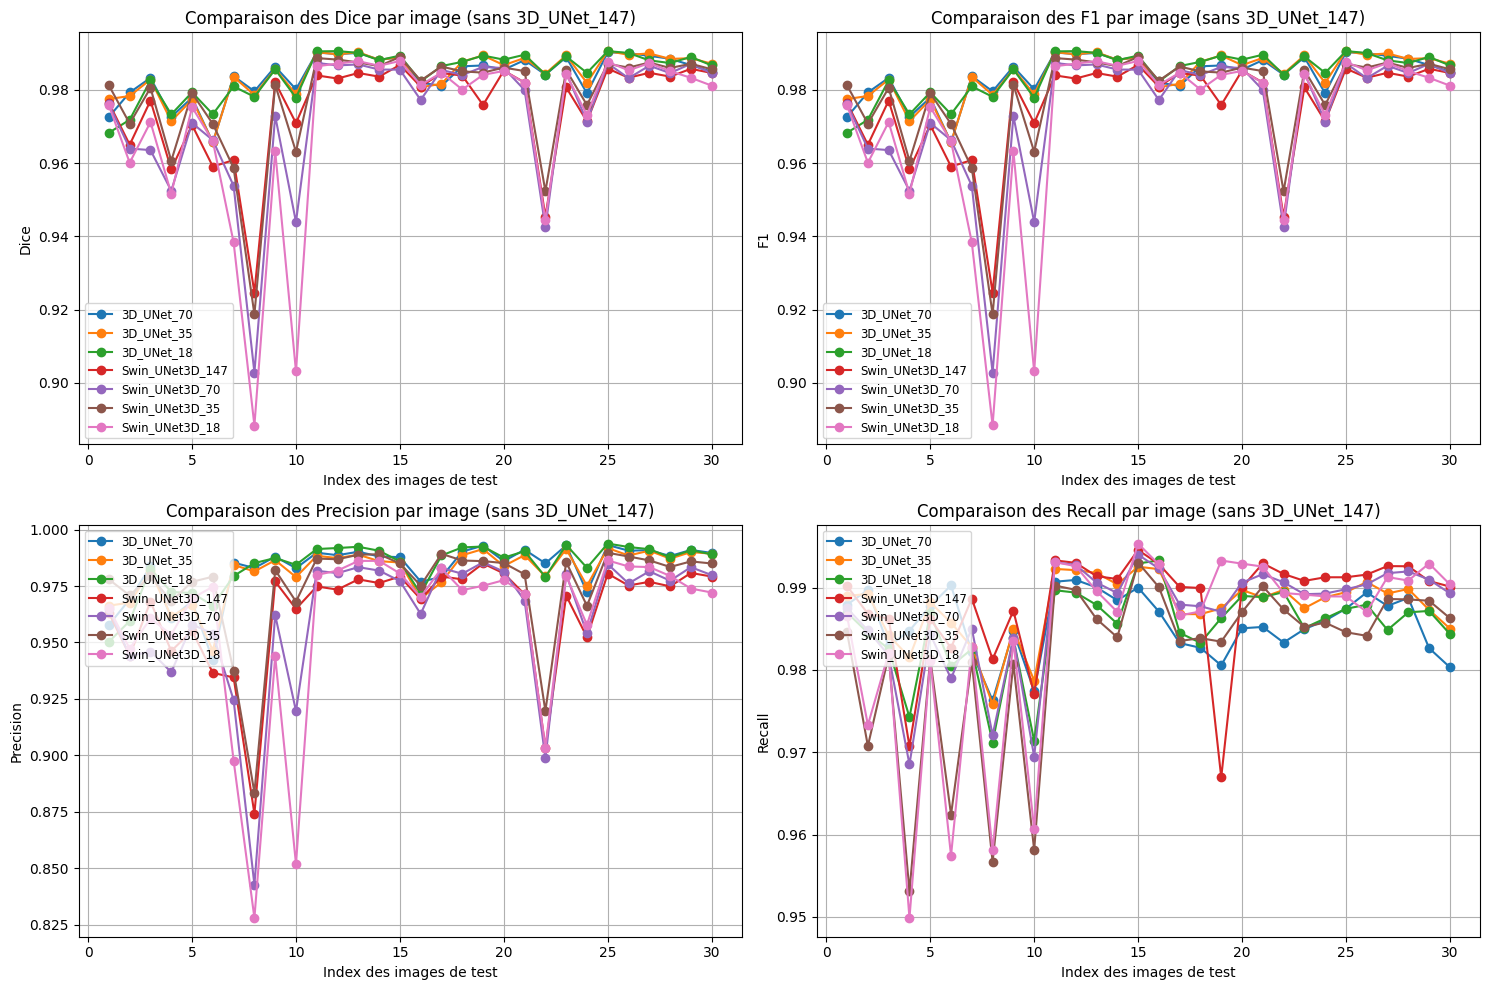

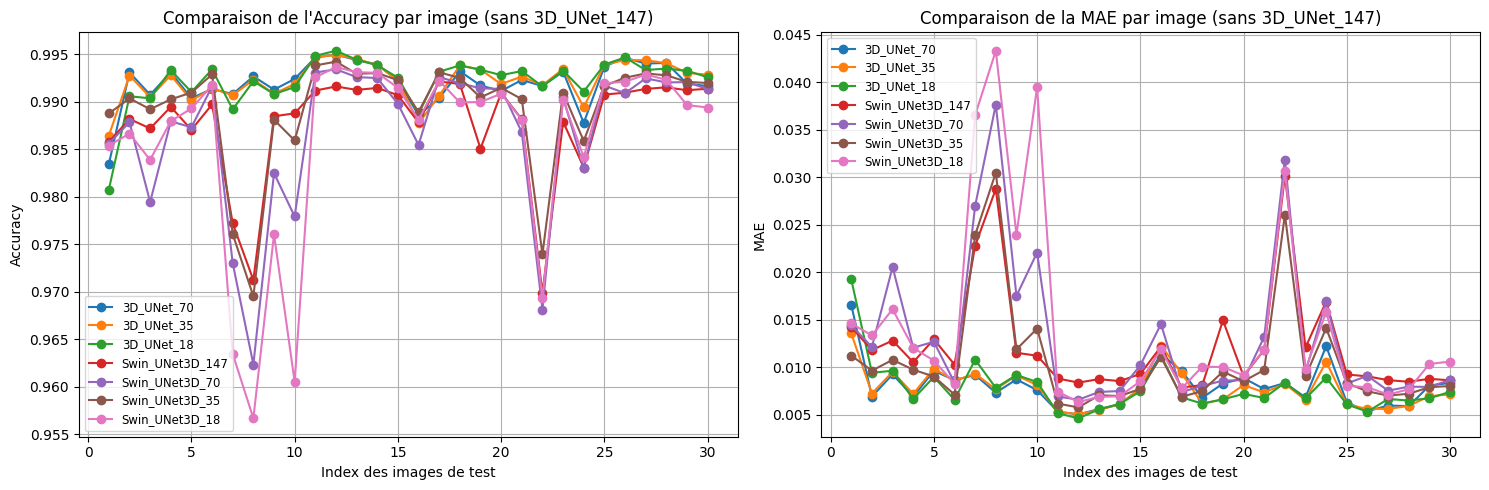

<ipython-input-15-4c1ecb803a78>:131: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(voxel_errors_data, labels=all_metrics_filtered.keys())


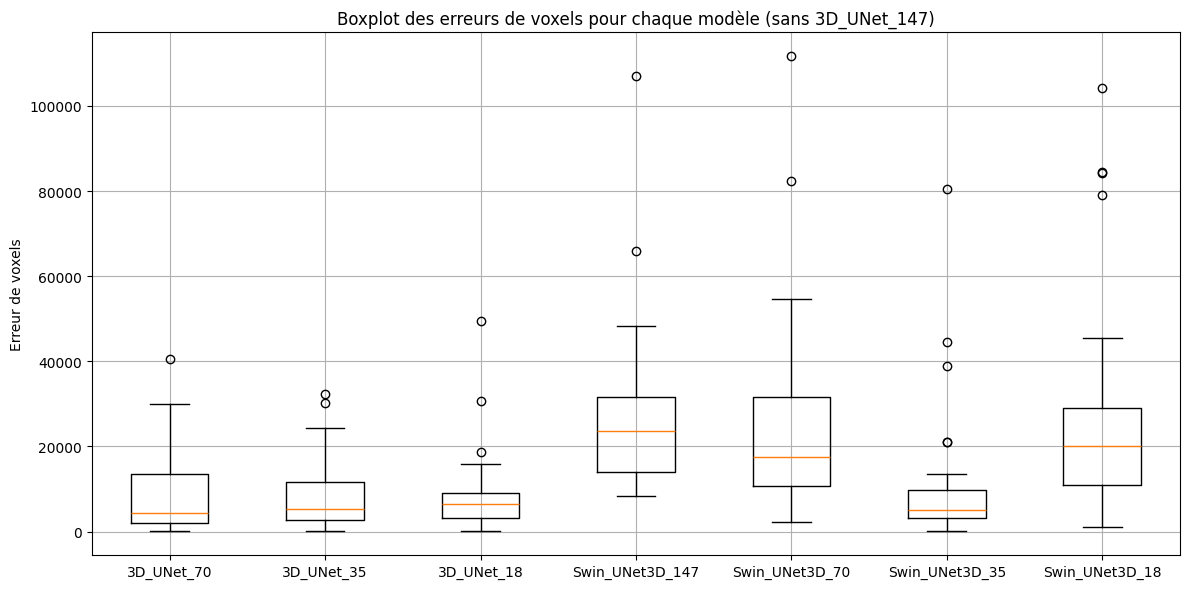

In [ ]:
import torch
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
from monai.transforms import AsDiscrete
from monai.inferers import sliding_window_inference
from monai.data import decollate_batch

# Définir un appareil pour l'exécution (GPU ou CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Utilisation de l'appareil : {device}")

# Définir les chemins vers les modèles (sans 3D_UNet_147)
base_path = '/content/drive/MyDrive/modèle/'
models_paths = {
    '3D_UNet_70': base_path + "3D_UNet_70.pth",
    '3D_UNet_35': base_path + "3D_UNet_35.pth",
    '3D_UNet_18': base_path + "3D_UNet_18.pth",
    'Swin_UNet3D_147': base_path + "Swin_UNet3D_147.pth",
    'Swin_UNet3D_70': base_path + "Swin_UNet3D_70.pth",
    'Swin_UNet3D_35': base_path + "Swin_UNet3D_35.pth",
    'Swin_UNet3D_18': base_path + "Swin_UNet3D_18.pth",
}

# Initialiser les modèles (sans 3D_UNet_147)
models = {}
for model_name, model_path in models_paths.items():
    if "UNet" in model_name and "Swin" not in model_name:
        model = UNet(
            spatial_dims=3,
            in_channels=1,
            out_channels=2,
            channels=(16, 32, 64, 128, 256),
            strides=(2, 2, 2, 2),
            num_res_units=2,
            norm='BATCH',  # Utilisation de la chaîne de caractères directement
        ).to(device)
    elif "Swin" in model_name:
        model = swinUnet_t_3D(
            hidden_dim=48,
            layers=[2, 2, 6, 2],
            heads=[3, 6, 12, 24],
            in_channel=1,
            num_classes=2,
            window_size=3
        ).to(device)
    else:
        raise ValueError(f"Nom de modèle non reconnu : {model_name}")

    try:
        model.load_state_dict(torch.load(model_path, map_location=device))
        model.eval()
        models[model_name] = model
        print(f"Modèle '{model_name}' chargé avec succès depuis '{model_path}'")
    except FileNotFoundError:
        print(f"Erreur: Le fichier de modèle '{model_path}' n'a pas été trouvé pour '{model_name}'.")
        exit()
    except RuntimeError as e:
        print(f"Erreur lors du chargement du modèle '{model_name}' depuis '{model_path}': {e}")
        exit()

# Transformations pour le post-traitement
post_pred = AsDiscrete(argmax=True, to_onehot=2)

# Listes pour stocker les résultats par modèle et par image (sans 3D_UNet_147)
models_to_keep = [k for k in models_paths.keys()]
all_metrics_filtered = {model_name: all_metrics[model_name] for model_name in models_to_keep if model_name in all_metrics}

# Calcul et affichage des résultats globaux (sans 3D_UNet_147)
print("\n--- Résultats Globaux (sans 3D_UNet_147) ---")
final_metrics = {}
for model_name, metrics in all_metrics_filtered.items():
    final_metrics[model_name] = {
        'Dice': (np.mean(metrics['dice']), np.std(metrics['dice'])),
        'F1': (np.mean(metrics['f1']), np.std(metrics['f1'])),
        'Precision': (np.mean(metrics['precision']), np.std(metrics['precision'])),
        'Recall': (np.mean(metrics['recall']), np.std(metrics['recall'])),
        'Accuracy': (np.mean(metrics['accuracy']), np.std(metrics['accuracy'])),
        'MAE': (np.mean(metrics['mae']), np.std(metrics['mae'])),
        'Voxel Error': (np.mean(metrics['voxel_error']), np.std(metrics['voxel_error'])),
    }
    print(f"\n{model_name} - Moyenne et Écart type :")
    for metric_name, (mean, std) in final_metrics[model_name].items():
        print(f"  {metric_name}: {mean:.4f} ± {std:.4f}")

# Affichage des résultats sous forme de graphiques (sans 3D_UNet_147)
num_test_images = len(next(iter(all_metrics_filtered.values()))['dice']) if all_metrics_filtered else 0
x_indices = np.arange(1, num_test_images + 1)

# 1. Graphiques des scores par image (sans 3D_UNet_147)
plt.figure(figsize=(15, 10))
for i, metric_name in enumerate(['dice', 'f1', 'precision', 'recall']):
    plt.subplot(2, 2, i + 1)
    for model_name in all_metrics_filtered:
        plt.plot(x_indices, all_metrics_filtered[model_name][metric_name], label=f"{model_name}", marker='o', linestyle='-')
    plt.xlabel("Index des images de test")
    plt.ylabel(metric_name.capitalize())
    plt.title(f"Comparaison des {metric_name.capitalize()} par image (sans 3D_UNet_147)")
    plt.legend(loc='lower left' if metric_name in ['dice', 'f1'] else 'upper left', fontsize='small')
    plt.grid(True)
plt.tight_layout()
plt.show()

# 2. Graphique de l'accuracy et MAE par image (sans 3D_UNet_147)
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
for model_name in all_metrics_filtered:
    plt.plot(x_indices, all_metrics_filtered[model_name]['accuracy'], label=f"{model_name}", marker='o', linestyle='-')
plt.xlabel("Index des images de test")
plt.ylabel("Accuracy")
plt.title("Comparaison de l'Accuracy par image (sans 3D_UNet_147)")
plt.legend(loc='lower left', fontsize='small')
plt.grid(True)

plt.subplot(1, 2, 2)
for model_name in all_metrics_filtered:
    plt.plot(x_indices, all_metrics_filtered[model_name]['mae'], label=f"{model_name}", marker='o', linestyle='-')
plt.xlabel("Index des images de test")
plt.ylabel("MAE")
plt.title("Comparaison de la MAE par image (sans 3D_UNet_147)")
plt.legend(loc='upper left', fontsize='small')
plt.grid(True)
plt.tight_layout()
plt.show()

# 3. Boxplot des erreurs de voxels (sans 3D_UNet_147)
plt.figure(figsize=(12, 6))
voxel_errors_data = [all_metrics_filtered[model_name]['voxel_error'] for model_name in all_metrics_filtered]
plt.boxplot(voxel_errors_data, labels=all_metrics_filtered.keys())
plt.title("Boxplot des erreurs de voxels pour chaque modèle (sans 3D_UNet_147)")
plt.ylabel("Erreur de voxels")
plt.grid(True)
plt.tight_layout()
plt.show()

Utilisation de l'appareil : cuda
Modèle '3D_UNet_70' chargé avec succès depuis '/content/drive/MyDrive/modèle/3D_UNet_70.pth'
Modèle '3D_UNet_35' chargé avec succès depuis '/content/drive/MyDrive/modèle/3D_UNet_35.pth'
Modèle '3D_UNet_18' chargé avec succès depuis '/content/drive/MyDrive/modèle/3D_UNet_18.pth'
Modèle 'Swin_UNet3D_147' chargé avec succès depuis '/content/drive/MyDrive/modèle/Swin_UNet3D_147.pth'
Modèle 'Swin_UNet3D_70' chargé avec succès depuis '/content/drive/MyDrive/modèle/Swin_UNet3D_70.pth'
Modèle 'Swin_UNet3D_35' chargé avec succès depuis '/content/drive/MyDrive/modèle/Swin_UNet3D_35.pth'
Modèle 'Swin_UNet3D_18' chargé avec succès depuis '/content/drive/MyDrive/modèle/Swin_UNet3D_18.pth'

--- Résultats Globaux (sans 3D_UNet_147) ---

3D_UNet_70 - Moyenne et Écart type :
  Dice: 0.9840 ± 0.0060
  F1: 0.9840 ± 0.0060
  Precision: 0.9825 ± 0.0119
  Recall: 0.9856 ± 0.0038
  Accuracy: 0.9920 ± 0.0023
  MAE: 0.0080 ± 0.0023
  Voxel Error: 8560.5000 ± 9194.9025

3D_UNet_

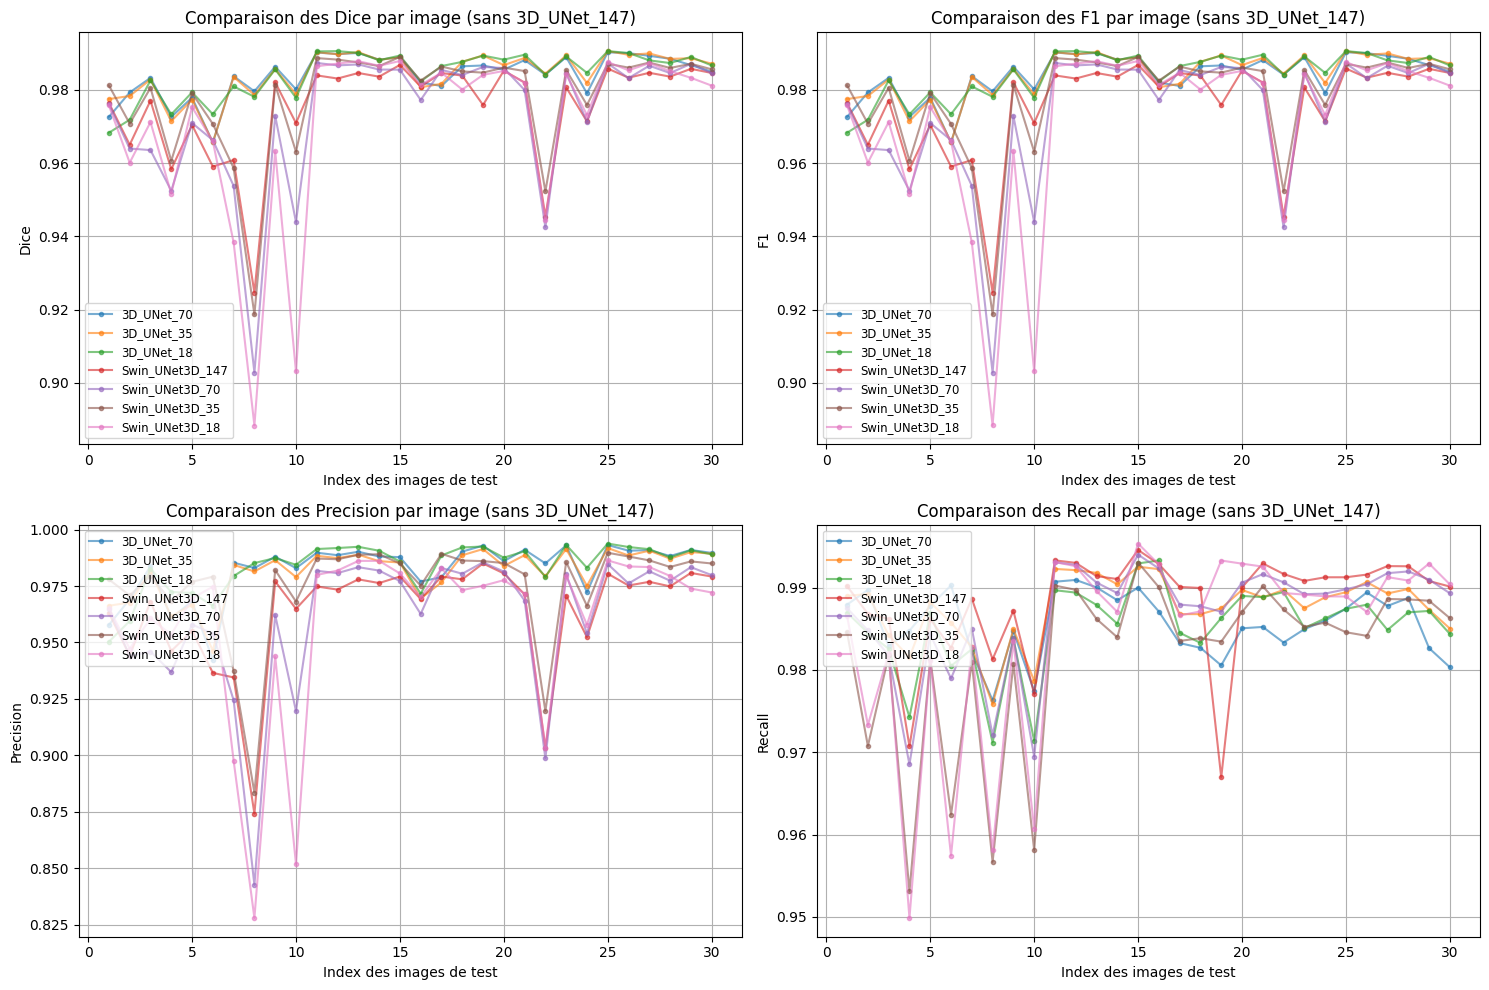

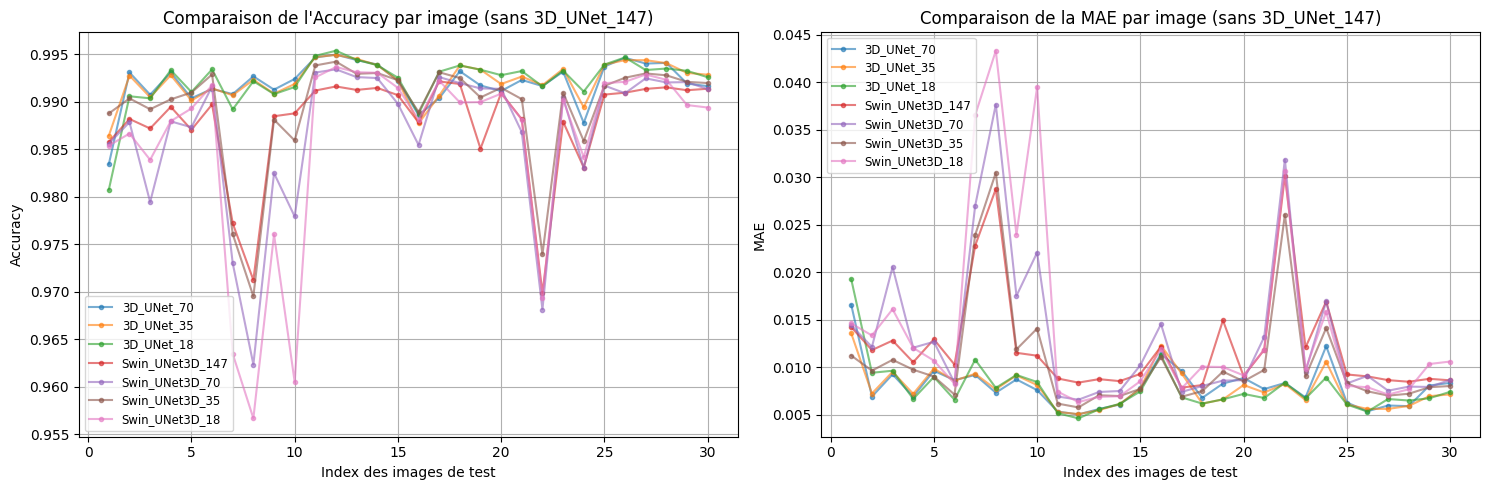

<ipython-input-19-3c2235d973b7>:134: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(voxel_errors_data, labels=model_names)


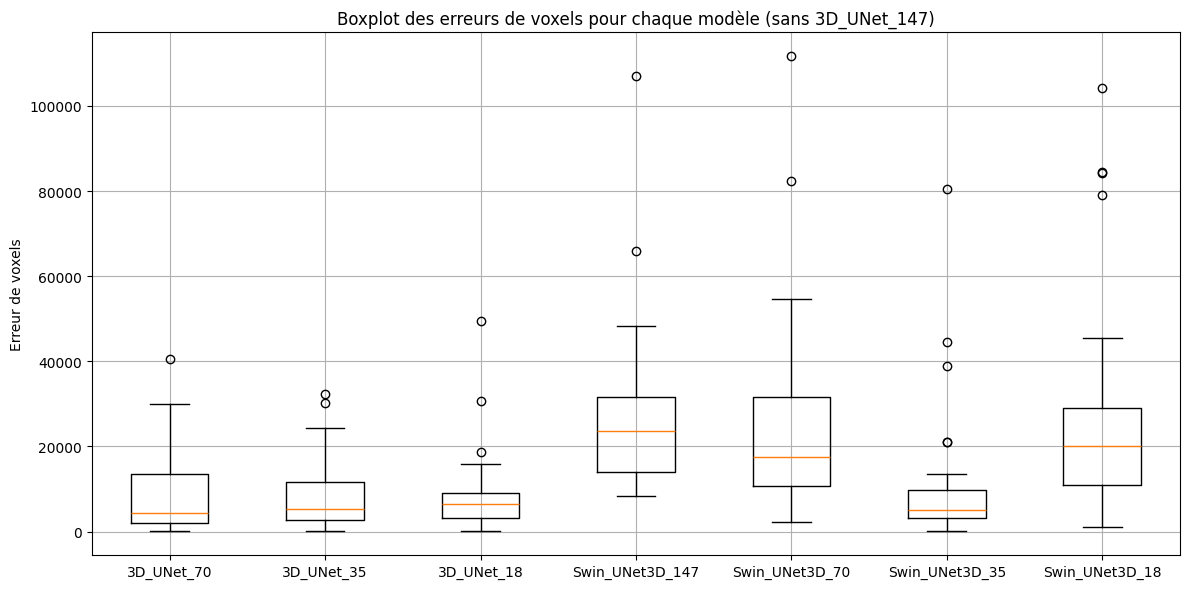

In [ ]:
import torch
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
from monai.transforms import AsDiscrete
from monai.inferers import sliding_window_inference
from monai.data import decollate_batch

# Définir un appareil pour l'exécution (GPU ou CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Utilisation de l'appareil : {device}")

# Définir les chemins vers les modèles (sans 3D_UNet_147)
base_path = '/content/drive/MyDrive/modèle/'
models_paths = {
    '3D_UNet_70': base_path + "3D_UNet_70.pth",
    '3D_UNet_35': base_path + "3D_UNet_35.pth",
    '3D_UNet_18': base_path + "3D_UNet_18.pth",
    'Swin_UNet3D_147': base_path + "Swin_UNet3D_147.pth",
    'Swin_UNet3D_70': base_path + "Swin_UNet3D_70.pth",
    'Swin_UNet3D_35': base_path + "Swin_UNet3D_35.pth",
    'Swin_UNet3D_18': base_path + "Swin_UNet3D_18.pth",
}

# Initialiser les modèles (sans 3D_UNet_147)
models = {}
for model_name, model_path in models_paths.items():
    if "UNet" in model_name and "Swin" not in model_name:
        model = UNet(
            spatial_dims=3,
            in_channels=1,
            out_channels=2,
            channels=(16, 32, 64, 128, 256),
            strides=(2, 2, 2, 2),
            num_res_units=2,
            norm='BATCH',  # Utilisation de la chaîne de caractères directement
        ).to(device)
    elif "Swin" in model_name:
        model = swinUnet_t_3D(
            hidden_dim=48,
            layers=[2, 2, 6, 2],
            heads=[3, 6, 12, 24],
            in_channel=1,
            num_classes=2,
            window_size=3
        ).to(device)
    else:
        raise ValueError(f"Nom de modèle non reconnu : {model_name}")

    try:
        model.load_state_dict(torch.load(model_path, map_location=device))
        model.eval()
        models[model_name] = model
        print(f"Modèle '{model_name}' chargé avec succès depuis '{model_path}'")
    except FileNotFoundError:
        print(f"Erreur: Le fichier de modèle '{model_path}' n'a pas été trouvé pour '{model_name}'.")
        exit()
    except RuntimeError as e:
        print(f"Erreur lors du chargement du modèle '{model_name}' depuis '{model_path}': {e}")
        exit()

# Transformations pour le post-traitement
post_pred = AsDiscrete(argmax=True, to_onehot=2)

# Listes pour stocker les résultats par modèle et par image (sans 3D_UNet_147)
models_to_keep = [k for k in models_paths.keys()]
all_metrics_filtered = {model_name: all_metrics[model_name] for model_name in models_to_keep if model_name in all_metrics}

# Calcul et affichage des résultats globaux (sans 3D_UNet_147)
print("\n--- Résultats Globaux (sans 3D_UNet_147) ---")
final_metrics = {}
for model_name, metrics in all_metrics_filtered.items():
    final_metrics[model_name] = {
        'Dice': (np.mean(metrics['dice']), np.std(metrics['dice'])),
        'F1': (np.mean(metrics['f1']), np.std(metrics['f1'])),
        'Precision': (np.mean(metrics['precision']), np.std(metrics['precision'])),
        'Recall': (np.mean(metrics['recall']), np.std(metrics['recall'])),
        'Accuracy': (np.mean(metrics['accuracy']), np.std(metrics['accuracy'])),
        'MAE': (np.mean(metrics['mae']), np.std(metrics['mae'])),
        'Voxel Error': (np.mean(metrics['voxel_error']), np.std(metrics['voxel_error'])),
    }
    print(f"\n{model_name} - Moyenne et Écart type :")
    for metric_name, (mean, std) in final_metrics[model_name].items():
        print(f"  {metric_name}: {mean:.4f} ± {std:.4f}")

# Affichage des résultats sous forme de graphiques (sans 3D_UNet_147)
num_test_images = len(next(iter(all_metrics_filtered.values()))['dice']) if all_metrics_filtered else 0
x_indices = np.arange(1, num_test_images + 1)
model_names = list(all_metrics_filtered.keys())
alpha_value = 0.6
marker_size = 3  # Réduction de la taille des marqueurs

# 1. Graphiques des scores par image (sans 3D_UNet_147)
plt.figure(figsize=(15, 10))
for i, metric_name in enumerate(['dice', 'f1', 'precision', 'recall']):
    plt.subplot(2, 2, i + 1)
    for model_name in model_names:
        plt.plot(x_indices, all_metrics_filtered[model_name][metric_name], label=f"{model_name}", marker='o', linestyle='-', alpha=alpha_value, markersize=marker_size)
    plt.xlabel("Index des images de test")
    plt.ylabel(metric_name.capitalize())
    plt.title(f"Comparaison des {metric_name.capitalize()} par image (sans 3D_UNet_147)")
    plt.legend(loc='lower left' if metric_name in ['dice', 'f1'] else 'upper left', fontsize='small')
    plt.grid(True)
plt.tight_layout()
plt.show()

# 2. Graphique de l'accuracy et MAE par image (sans 3D_UNet_147)
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
for model_name in model_names:
    plt.plot(x_indices, all_metrics_filtered[model_name]['accuracy'], label=f"{model_name}", marker='o', linestyle='-', alpha=alpha_value, markersize=marker_size)
plt.xlabel("Index des images de test")
plt.ylabel("Accuracy")
plt.title("Comparaison de l'Accuracy par image (sans 3D_UNet_147)")
plt.legend(loc='lower left', fontsize='small')
plt.grid(True)

plt.subplot(1, 2, 2)
for model_name in model_names:
    plt.plot(x_indices, all_metrics_filtered[model_name]['mae'], label=f"{model_name}", marker='o', linestyle='-', alpha=alpha_value, markersize=marker_size)
plt.xlabel("Index des images de test")
plt.ylabel("MAE")
plt.title("Comparaison de la MAE par image (sans 3D_UNet_147)")
plt.legend(loc='upper left', fontsize='small')
plt.grid(True)
plt.tight_layout()
plt.show()

# 3. Boxplot des erreurs de voxels (sans 3D_UNet_147)
plt.figure(figsize=(12, 6))
voxel_errors_data = [all_metrics_filtered[model_name]['voxel_error'] for model_name in model_names]
plt.boxplot(voxel_errors_data, labels=model_names)
plt.title("Boxplot des erreurs de voxels pour chaque modèle (sans 3D_UNet_147)")
plt.ylabel("Erreur de voxels")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import torch
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
from monai.transforms import AsDiscrete
from monai.inferers import sliding_window_inference
from monai.data import decollate_batch
import os

# Définir un appareil pour l'exécution (GPU ou CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Utilisation de l'appareil : {device}")

# Définir les chemins vers les modèles (sans 3D_UNet_147)
base_path = '/content/drive/MyDrive/modèle/'
models_paths = {
    '3D_UNet_70': base_path + "3D_UNet_70.pth",
    '3D_UNet_35': base_path + "3D_UNet_35.pth",
    '3D_UNet_18': base_path + "3D_UNet_18.pth",
    'Swin_UNet3D_147': base_path + "Swin_UNet3D_147.pth",
    'Swin_UNet3D_70': base_path + "Swin_UNet3D_70.pth",
    'Swin_UNet3D_35': base_path + "Swin_UNet3D_35.pth",
    'Swin_UNet3D_18': base_path + "Swin_UNet3D_18.pth",
}

# Initialiser les modèles (sans 3D_UNet_147)
models = {}
for model_name, model_path in models_paths.items():
    if "UNet" in model_name and "Swin" not in model_name:
        model = UNet(
            spatial_dims=3,
            in_channels=1,
            out_channels=2,
            channels=(16, 32, 64, 128, 256),
            strides=(2, 2, 2, 2),
            num_res_units=2,
            norm='BATCH',  # Utilisation de la chaîne de caractères directement
        ).to(device)
    elif "Swin" in model_name:
        model = swinUnet_t_3D(
            hidden_dim=48,
            layers=[2, 2, 6, 2],
            heads=[3, 6, 12, 24],
            in_channel=1,
            num_classes=2,
            window_size=3
        ).to(device)
    else:
        raise ValueError(f"Nom de modèle non reconnu : {model_name}")

    try:
        model.load_state_dict(torch.load(model_path, map_location=device))
        model.eval()
        models[model_name] = model
        print(f"Modèle '{model_name}' chargé avec succès depuis '{model_path}'")
    except FileNotFoundError:
        print(f"Erreur: Le fichier de modèle '{model_path}' n'a pas été trouvé pour '{model_name}'.")
        exit()
    except RuntimeError as e:
        print(f"Erreur lors du chargement du modèle '{model_name}' depuis '{model_path}': {e}")
        exit()

# Transformations pour le post-traitement
post_pred = AsDiscrete(argmax=True, to_onehot=2)

# Listes pour stocker les résultats par modèle et par image
models_to_keep = [k for k in models_paths.keys()]
all_metrics_filtered = {model_name: all_metrics[model_name] for model_name in models_to_keep if model_name in all_metrics}

# Calcul et affichage des résultats globaux
print("\n--- Résultats Globaux (sans 3D_UNet_147) ---")
final_metrics = {}
for model_name, metrics in all_metrics_filtered.items():
    final_metrics[model_name] = {
        'Dice': (np.mean(metrics['dice']), np.std(metrics['dice'])),
        'F1': (np.mean(metrics['f1']), np.std(metrics['f1'])),
        'Precision': (np.mean(metrics['precision']), np.std(metrics['precision'])),
        'Recall': (np.mean(metrics['recall']), np.std(metrics['recall'])),
        'Accuracy': (np.mean(metrics['accuracy']), np.std(metrics['accuracy'])),
        'MAE': (np.mean(metrics['mae']), np.std(metrics['mae'])),
        'Voxel Error': (np.mean(metrics['voxel_error']), np.std(metrics['voxel_error'])),
    }
    print(f"\n{model_name} - Moyenne et Écart type :")
    for metric_name, (mean, std) in final_metrics[model_name].items():
        print(f"  {metric_name}: {mean:.4f} ± {std:.4f}")


num_test_images = len(next(iter(all_metrics_filtered.values()))['dice']) if all_metrics_filtered else 0
x_indices = np.arange(1, num_test_images + 1)
model_names = list(all_metrics_filtered.keys())
alpha_value = 0.6
marker_size = 3
output_dir = '/content/drive/MyDrive/graphes_modeles/'

os.makedirs(output_dir, exist_ok=True)

# 1. Graphiques des scores par image
for metric_name in ['dice', 'f1', 'precision', 'recall']:
    plt.figure(figsize=(10, 6))
    for model_name in model_names:
        plt.plot(x_indices, all_metrics_filtered[model_name][metric_name], label=f"{model_name}", marker='o', linestyle='-', alpha=alpha_value, markersize=marker_size)
    plt.xlabel("Index des images de test")
    plt.ylabel(metric_name.capitalize())
    plt.title(f"Comparaison du {metric_name.capitalize()} par image")
    plt.legend(loc='best', fontsize='small')
    plt.grid(True)
    plt.tight_layout()
    filename = os.path.join(output_dir, f"comparaison_{metric_name}_par_image.png")
    plt.savefig(filename)
    plt.close()
    print(f"Graphique sauvegardé : {filename}")

# 2. Graphiques de l'accuracy et MAE par image
plt.figure(figsize=(10, 6))
for model_name in model_names:
    plt.plot(x_indices, all_metrics_filtered[model_name]['accuracy'], label=f"{model_name}", marker='o', linestyle='-', alpha=alpha_value, markersize=marker_size)
plt.xlabel("Index des images de test")
plt.ylabel("Accuracy")
plt.title("Comparaison de l'Accuracy par image")
plt.legend(loc='best', fontsize='small')
plt.grid(True)
plt.tight_layout()
filename = os.path.join(output_dir, "comparaison_accuracy_par_image.png")
plt.savefig(filename)
plt.close()
print(f"Graphique sauvegardé : {filename}")

plt.figure(figsize=(10, 6))
for model_name in model_names:
    plt.plot(x_indices, all_metrics_filtered[model_name]['mae'], label=f"{model_name}", marker='o', linestyle='-', alpha=alpha_value, markersize=marker_size)
plt.xlabel("Index des images de test")
plt.ylabel("MAE")
plt.title("Comparaison de la MAE par image")
plt.legend(loc='best', fontsize='small')
plt.grid(True)
plt.tight_layout()
filename = os.path.join(output_dir, "comparaison_mae_par_image.png")
plt.savefig(filename)
plt.close()
print(f"Graphique sauvegardé : {filename}")

# 3. Graphique des erreurs de voxels
plt.figure(figsize=(10, 6))
plt.boxplot([all_metrics_filtered[model_name]['voxel_error'] for model_name in model_names], labels=model_names)
plt.title("Boxplot des erreurs de voxels pour chaque modèle")
plt.ylabel("Erreur de voxels")
plt.grid(True)
plt.tight_layout()
filename = os.path.join(output_dir, "boxplot_erreur_voxels.png")
plt.savefig(filename)
plt.close()
print(f"Graphique sauvegardé : {filename}")

Utilisation de l'appareil : cuda
Modèle '3D_UNet_70' chargé avec succès depuis '/content/drive/MyDrive/modèle/3D_UNet_70.pth'
Modèle '3D_UNet_35' chargé avec succès depuis '/content/drive/MyDrive/modèle/3D_UNet_35.pth'
Modèle '3D_UNet_18' chargé avec succès depuis '/content/drive/MyDrive/modèle/3D_UNet_18.pth'
Modèle 'Swin_UNet3D_147' chargé avec succès depuis '/content/drive/MyDrive/modèle/Swin_UNet3D_147.pth'
Modèle 'Swin_UNet3D_70' chargé avec succès depuis '/content/drive/MyDrive/modèle/Swin_UNet3D_70.pth'
Modèle 'Swin_UNet3D_35' chargé avec succès depuis '/content/drive/MyDrive/modèle/Swin_UNet3D_35.pth'
Modèle 'Swin_UNet3D_18' chargé avec succès depuis '/content/drive/MyDrive/modèle/Swin_UNet3D_18.pth'

--- Résultats Globaux (sans 3D_UNet_147) ---

3D_UNet_70 - Moyenne et Écart type :
  Dice: 0.9840 ± 0.0060
  F1: 0.9840 ± 0.0060
  Precision: 0.9825 ± 0.0119
  Recall: 0.9856 ± 0.0038
  Accuracy: 0.9920 ± 0.0023
  MAE: 0.0080 ± 0.0023
  Voxel Error: 8560.5000 ± 9194.9025

3D_UNet_

<ipython-input-20-96e3efb413bb>:147: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([all_metrics_filtered[model_name]['voxel_error'] for model_name in model_names], labels=model_names)


Graphique sauvegardé : /content/drive/MyDrive/graphes_modeles/boxplot_erreur_voxels.png
